In [ ]:
!pip install pandas numpy scikit-learn tensorflow beautifulsoup4 requests

✅ Dataset generated successfully!
🧠 Training LSTM Neural Network and gathering metrics...
📊 Generating research paper visualizations...


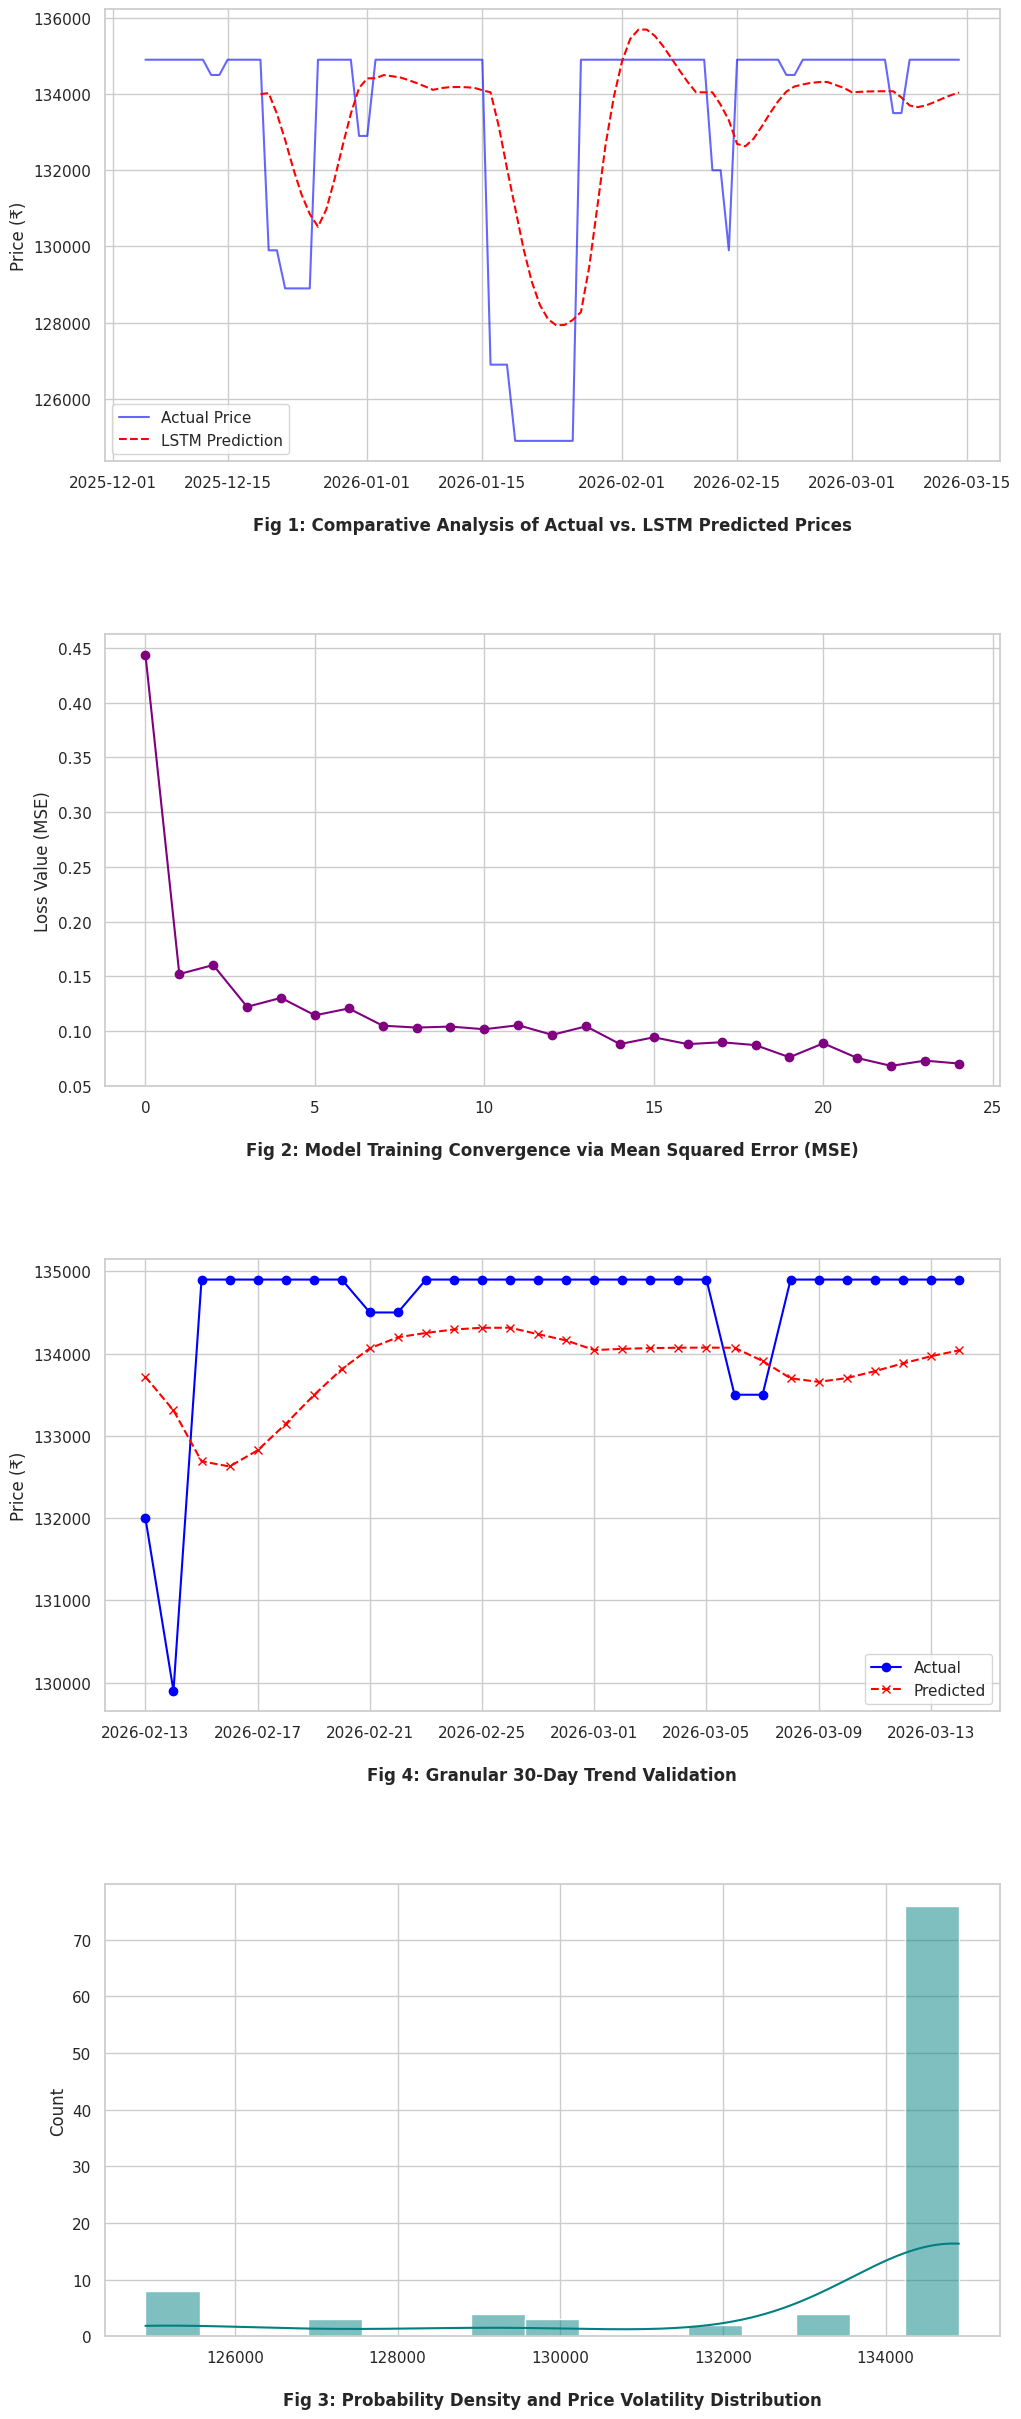

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
import os

warnings.filterwarnings('ignore') # Hides annoying TensorFlow warnings

# Set aesthetic style for professional research paper graphs
sns.set_theme(style="whitegrid")

# ==========================================
# PHASE 1: GENERATE DATASET
# ==========================================
csv_content = """Date,Price
2025-12-05,134900.0
2025-12-06,134900.0
2025-12-07,134900.0
2025-12-08,134900.0
2025-12-09,134900.0
2025-12-10,134900.0
2025-12-11,134900.0
2025-12-12,134900.0
2025-12-13,134500.0
2025-12-14,134500.0
2025-12-15,134900.0
2025-12-16,134900.0
2025-12-17,134900.0
2025-12-18,134900.0
2025-12-19,134900.0
2025-12-20,129900.0
2025-12-21,129900.0
2025-12-22,128900.0
2025-12-23,128900.0
2025-12-24,128900.0
2025-12-25,128900.0
2025-12-26,134900.0
2025-12-27,134900.0
2025-12-28,134900.0
2025-12-29,134900.0
2025-12-30,134900.0
2025-12-31,132900.0
2026-01-01,132900.0
2026-01-02,134900.0
2026-01-03,134900.0
2026-01-04,134900.0
2026-01-05,134900.0
2026-01-06,134900.0
2026-01-07,134900.0
2026-01-08,134900.0
2026-01-09,134900.0
2026-01-10,134900.0
2026-01-11,134900.0
2026-01-12,134900.0
2026-01-13,134900.0
2026-01-14,134900.0
2026-01-15,134900.0
2026-01-16,126900.0
2026-01-17,126900.0
2026-01-18,126900.0
2026-01-19,124900.0
2026-01-20,124900.0
2026-01-21,124900.0
2026-01-22,124900.0
2026-01-23,124900.0
2026-01-24,124900.0
2026-01-25,124900.0
2026-01-26,124900.0
2026-01-27,134900.0
2026-01-28,134900.0
2026-01-29,134900.0
2026-01-30,134900.0
2026-01-31,134900.0
2026-02-01,134900.0
2026-02-02,134900.0
2026-02-03,134900.0
2026-02-04,134900.0
2026-02-05,134900.0
2026-02-06,134900.0
2026-02-07,134900.0
2026-02-08,134900.0
2026-02-09,134900.0
2026-02-10,134900.0
2026-02-11,134900.0
2026-02-12,132000.0
2026-02-13,132000.0
2026-02-14,129900.0
2026-02-15,134900.0
2026-02-16,134900.0
2026-02-17,134900.0
2026-02-18,134900.0
2026-02-19,134900.0
2026-02-20,134900.0
2026-02-21,134500.0
2026-02-22,134500.0
2026-02-23,134900.0
2026-02-24,134900.0
2026-02-25,134900.0
2026-02-26,134900.0
2026-02-27,134900.0
2026-02-28,134900.0
2026-03-01,134900.0
2026-03-02,134900.0
2026-03-03,134900.0
2026-03-04,134900.0
2026-03-05,134900.0
2026-03-06,133500.0
2026-03-07,133500.0
2026-03-08,134900.0
2026-03-09,134900.0
2026-03-10,134900.0
2026-03-11,134900.0
2026-03-12,134900.0
2026-03-13,134900.0
2026-03-14,134900.0"""

csv_filename = 'amazon_price_history.csv'
with open(csv_filename, 'w') as file:
    file.write(csv_content)
print("✅ Dataset generated successfully!")

# # ==========================================
# # PHASE 2 & 3: PREPROCESSING & LSTM MODELING
# # ==========================================
# def build_and_train_lstm(historical_data):
#     """Trains an LSTM model on the CSV price data."""
#     scaler = MinMaxScaler(feature_range=(0, 1))
#     scaled_data = scaler.fit_transform(historical_data['Price'].values.reshape(-1, 1))

#     # Using the last 14 days to predict the next day
#     prediction_days = 14
#     x_train, y_train = [], []

#     for x in range(prediction_days, len(scaled_data)):
#         x_train.append(scaled_data[x - prediction_days:x, 0])
#         y_train.append(scaled_data[x, 0])

#     x_train, y_train = np.array(x_train), np.array(y_train)
#     x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

#     model = Sequential()
#     model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
#     model.add(Dropout(0.2))
#     model.add(LSTM(units=50, return_sequences=False))
#     model.add(Dropout(0.2))
#     model.add(Dense(units=1))

#     model.compile(optimizer='adam', loss='mean_squared_error')
#     model.fit(x_train, y_train, epochs=20, batch_size=16, verbose=0)

#     return model, scaler, prediction_days

# ==========================================
# PHASE 2 & 3: MODELING (Updated to save History)
# ==========================================
def build_and_train_lstm(historical_data):
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(historical_data['Price'].values.reshape(-1, 1))

    prediction_days = 14
    x_train, y_train = [], []

    for x in range(prediction_days, len(scaled_data)):
        x_train.append(scaled_data[x - prediction_days:x, 0])
        y_train.append(scaled_data[x, 0])

    x_train, y_train = np.array(x_train), np.array(y_train)
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))

    model.compile(optimizer='adam', loss='mean_squared_error')

    # NEW: We save the 'history' of the training to plot the loss curve
    history = model.fit(x_train, y_train, epochs=25, batch_size=16, verbose=0)

    # NEW: Generate predictions for the training set to see how well it fits
    train_predictions = model.predict(x_train, verbose=0)
    train_predictions = scaler.inverse_transform(train_predictions)

    return model, scaler, prediction_days, history, train_predictions

# ==========================================
# RESEARCH PAPER VISUALIZATIONS
# ==========================================
# def plot_research_graphs(df_history, history, train_predictions, lookback_days):
#     fig = plt.figure(figsize=(16, 12))

#     # --- Graph 1: Actual vs. Predicted Trend ---
#     ax1 = fig.add_subplot(2, 2, 1)
#     # The actual prices
#     ax1.plot(df_history['Date'], df_history['Price'], color='blue', label='Actual Price', alpha=0.6, linewidth=2)

#     # The predicted prices (shifted by the lookback window)
#     pred_dates = df_history['Date'].iloc[lookback_days:]
#     ax1.plot(pred_dates, train_predictions, color='red', label='LSTM Fit (Predicted)', linestyle='--', linewidth=2)

#     ax1.set_title('Fig 1: LSTM Model Fit (Actual vs. Predicted)', fontsize=14, fontweight='bold')
#     ax1.set_ylabel('Price (₹)')
#     ax1.tick_params(axis='x', rotation=45)
#     ax1.legend()

#     # --- Graph 2: Model Training Loss Curve ---
#     ax2 = fig.add_subplot(2, 2, 2)
#     ax2.plot(history.history['loss'], color='purple', linewidth=2, marker='o')
#     ax2.set_title('Fig 2: Model Training Loss (MSE) over Epochs', fontsize=14, fontweight='bold')
#     ax2.set_xlabel('Epoch')
#     ax2.set_ylabel('Mean Squared Error (Loss)')

#     # --- Graph 3: Price Distribution (EDA) ---
#     ax3 = fig.add_subplot(2, 2, 3)
#     sns.histplot(df_history['Price'], bins=15, kde=True, color='teal', ax=ax3)
#     ax3.set_title('Fig 3: Price Volatility Distribution', fontsize=14, fontweight='bold')
#     ax3.set_xlabel('Price (₹)')
#     ax3.set_ylabel('Frequency (Days)')

#     # --- Graph 4: 30-Day Zoomed View ---
#     ax4 = fig.add_subplot(2, 2, 4)
#     last_30_dates = df_history['Date'].iloc[-30:]
#     last_30_actual = df_history['Price'].iloc[-30:]
#     last_30_pred = train_predictions[-30:]

#     ax4.plot(last_30_dates, last_30_actual, color='blue', marker='o', label='Actual', alpha=0.7)
#     ax4.plot(last_30_dates, last_30_pred, color='red', marker='x', linestyle='--', label='Predicted')
#     ax4.set_title('Fig 4: 30-Day Zoom (Recent Trends)', fontsize=14, fontweight='bold')
#     ax4.tick_params(axis='x', rotation=45)
#     ax4.legend()

#     plt.tight_layout(pad=3.0)
#     plt.show()

def plot_research_graphs(df_history, history, train_predictions, lookback_days):
    # High-resolution vertical layout
    fig = plt.figure(figsize=(12, 26))

    # --- Graph 1: Actual vs. Predicted ---
    ax1 = fig.add_subplot(4, 1, 1)
    ax1.plot(df_history['Date'], df_history['Price'], color='blue', label='Actual Price', alpha=0.6)
    pred_dates = df_history['Date'].iloc[lookback_days:]
    ax1.plot(pred_dates, train_predictions, color='red', label='LSTM Prediction', linestyle='--')
    ax1.set_ylabel('Price (₹)')
    # Label moved to bottom
    ax1.set_xlabel('\nFig 1: Comparative Analysis of Actual vs. LSTM Predicted Prices', fontsize=12, fontweight='bold')
    ax1.legend()

    # --- Graph 2: Loss Curve ---
    ax2 = fig.add_subplot(4, 1, 2)
    ax2.plot(history.history['loss'], color='purple', marker='o')
    ax2.set_ylabel('Loss Value (MSE)')
    # Label moved to bottom
    ax2.set_xlabel('\nFig 2: Model Training Convergence via Mean Squared Error (MSE)', fontsize=12, fontweight='bold')

    # --- Graph 3: Price Distribution ---
    ax3 = fig.add_subplot(4, 1, 4) # Swapped for better flow
    sns.histplot(df_history['Price'], bins=15, kde=True, color='teal', ax=ax3)
    # Label moved to bottom
    ax3.set_xlabel('\nFig 3: Probability Density and Price Volatility Distribution', fontsize=12, fontweight='bold')

    # --- Graph 4: 30-Day Zoom ---
    ax4 = fig.add_subplot(4, 1, 3)
    last_30_dates = df_history['Date'].iloc[-30:]
    ax4.plot(last_30_dates, df_history['Price'].iloc[-30:], color='blue', marker='o', label='Actual')
    ax4.plot(last_30_dates, train_predictions[-30:], color='red', marker='x', linestyle='--', label='Predicted')
    ax4.set_ylabel('Price (₹)')
    # Label moved to bottom
    ax4.set_xlabel('\nFig 4: Granular 30-Day Trend Validation', fontsize=12, fontweight='bold')
    ax4.legend()

    plt.tight_layout(pad=6.0)
    plt.show()


def predict_future_price(model, scaler, recent_data, prediction_days):
    """Predicts tomorrow's price."""
    scaled_recent = scaler.transform(recent_data['Price'].values.reshape(-1, 1))
    x_test = [scaled_recent[-prediction_days:, 0]]
    x_test = np.array(x_test)
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

    predicted_price = model.predict(x_test, verbose=0)
    return scaler.inverse_transform(predicted_price)[0][0]

# ==========================================
# PHASE 4: BUY/WAIT SIGNAL & VISUALIZATION
# ==========================================
def buy_or_wait_signal(current_price, predicted_price, threshold=0.015):
    """Determines if the user should buy or wait."""
    price_diff = (predicted_price - current_price) / current_price

    print(f"Current Live Price: ₹{current_price:,.2f}")
    print(f"LSTM Predicted Price (Tomorrow): ₹{predicted_price:,.2f}")

    if price_diff <= -threshold:
        return "🛑 WAIT: The AI predicts a significant price drop soon."
    elif price_diff < 0:
        return f"⚠️ HOLD: The AI predicts a minor drop of ₹{abs(predicted_price - current_price):,.2f}. Wait if you want maximum savings."
    else:
        return "✅ BUY NOW: The price is expected to rise or remain strictly stable."

def plot_results(df_history, predicted_price):
    """Generates a graph visualizing the timeline and prediction."""
    plt.figure(figsize=(12, 6))
    plt.plot(df_history['Date'], df_history['Price'], color='blue', label='Historical Price')

    # Plotting the prediction as a red dot on the next day
    next_day = df_history['Date'].iloc[-1] + pd.Timedelta(days=1)
    plt.scatter(next_day, predicted_price, color='red', s=100, label='LSTM Prediction (Tomorrow)', zorder=5)

    plt.title('SmartPrice AI: E-Commerce Price Prediction')
    plt.xlabel('Date')
    plt.ylabel('Price (₹)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# # --- Execution ---
# if __name__ == "__main__":
#     try:
#         df_history = pd.read_csv(csv_filename)
#         df_history['Date'] = pd.to_datetime(df_history['Date'])
#         df_history = df_history.sort_values('Date')

#         print(f"✅ Successfully loaded {len(df_history)} days of actual product data.")
#         print("🧠 Training LSTM Neural Network on historical patterns (this takes a few seconds)...")

#         model, scaler, lookback_days = build_and_train_lstm(df_history)
#         current_live_price = df_history['Price'].iloc[-1]
#         predicted = predict_future_price(model, scaler, df_history, lookback_days)
#         recommendation = buy_or_wait_signal(current_live_price, predicted)

#         print("\n" + "="*40)
#         print("--- SmartPrice AI Recommendation ---")
#         print(recommendation)
#         print("="*40 + "\n")

#         # Generate the graph
#         plot_results(df_history, predicted)

#     except FileNotFoundError:
#         print(f"Error: Could not find '{csv_filename}'.")


# --- Execution ---
if __name__ == "__main__":
    csv_filename = 'amazon_price_history.csv'

    try:
        df_history = pd.read_csv(csv_filename)
        df_history['Date'] = pd.to_datetime(df_history['Date'])
        df_history = df_history.sort_values('Date')

        print("🧠 Training LSTM Neural Network and gathering metrics...")

        model, scaler, lookback_days, history, train_preds = build_and_train_lstm(df_history)

        print("📊 Generating research paper visualizations...")
        plot_research_graphs(df_history, history, train_preds, lookback_days)

    except FileNotFoundError:
        print(f"Error: Could not find '{csv_filename}'.")